# FAFB Neurons Dataset — Visualization

Exploratory visualization of `neurons.csv.gz` (115,151 neurons).

**Columns:** `root_id`, `super_class`, `sub_class`, `nt_type`, `nt_score`, `nt_type`, `nt_type`, `side`

**Topics covered:**
1. Data overview & missing values
2. super_class distribution (top-30)
3. nt_type distribution
4. nt_score distribution
5. Body part distribution
6. sub_class (top-20)
7. NT type × Body part heatmap
8. Top-15 regions × NT type heatmap
9. Verified vs nt_type comparison
10. Summary statistics table

In [1]:
# ── Imports & data loading ───────────────────────────────────────────────────
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')   # make fafb_utils importable from this directory

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from fafb_utils import (
    load_neurons,
    neuron_region_counts,
    neuron_nt_type_counts,
    neuron_body_part_counts,
    neuron_community_label_counts,
    neuron_nt_confidence_stats,
    missing_data_summary,
    plot_bar, plot_barh, plot_histogram, plot_pie, plot_heatmap,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

neurons_df = load_neurons()
print(f'Loaded neurons: {neurons_df.shape[0]:,} rows x {neurons_df.shape[1]} columns')
neurons_df.head(3)

Loaded neurons: 138,327 rows x 14 columns


,root_id,primary_type_x,additional_type(s)_x,flow,super_class,class,sub_class,hemilineage,side,nerve,nt_type,nt_score,primary_type_y,additional_type(s)_y
0,720575940599457990,T4b,NaN,intrinsic,optic,optic_lobe_intrinsic,t4_neuron,NaN,right,NaN,ACH,1.0,T4b,NaN
1,720575940599763910,T5b,NaN,intrinsic,optic,optic_lobe_intrinsic,t5_neuron,NaN,right,NaN,ACH,1.0,T5b,NaN
2,720575940600623020,Dm3q,NaN,intrinsic,optic,optic_lobe_intrinsic,distal_medulla,NaN,right,NaN,GLUT,1.0,Dm3q,NaN


## 1. Data Overview & Missing Values

Shape: (138327, 14)

Dtypes:
root_id                   int64
primary_type_x           object
additional_type(s)_x     object
flow                     object
super_class              object
class                    object
sub_class                object
hemilineage              object
side                     object
nerve                    object
nt_type                  object
nt_score                float64
primary_type_y           object
additional_type(s)_y     object
dtype: object

Basic stats:


,root_id,primary_type_x,additional_type(s)_x,flow,super_class,class,sub_class,hemilineage,side,nerve,nt_type,nt_score,primary_type_y,additional_type(s)_y
count,1.383270e+05,138327,13956,138327,138327,107105,99877,37420,138297,9203,136778,136778.0,138327,13956
unique,NaN,8772,1508,3,10,29,117,214,3,8,6,NaN,8772,1508
top,NaN,R1-6,KCab-m,intrinsic,optic,optic_lobe_intrinsic,transmedullary,putative_primary,left,AN,ACH,NaN,R1-6,KCab-m
freq,NaN,8456,957,117982,77560,77382,17996,3867,69431,3452,93624,NaN,8456,957
mean,7.205759e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
std,1.007158e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
min,7.205759e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
25%,7.205759e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
50%,7.205759e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
75%,7.205759e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN



Missing value summary:


,missing_count,missing_pct
nerve,129124,93.35
additional_type(s)_x,124371,89.91
additional_type(s)_y,124371,89.91
hemilineage,100907,72.95
sub_class,38450,27.80
class,31222,22.57
nt_type,1549,1.12
nt_score,1549,1.12
side,30,0.02
root_id,0,0.00


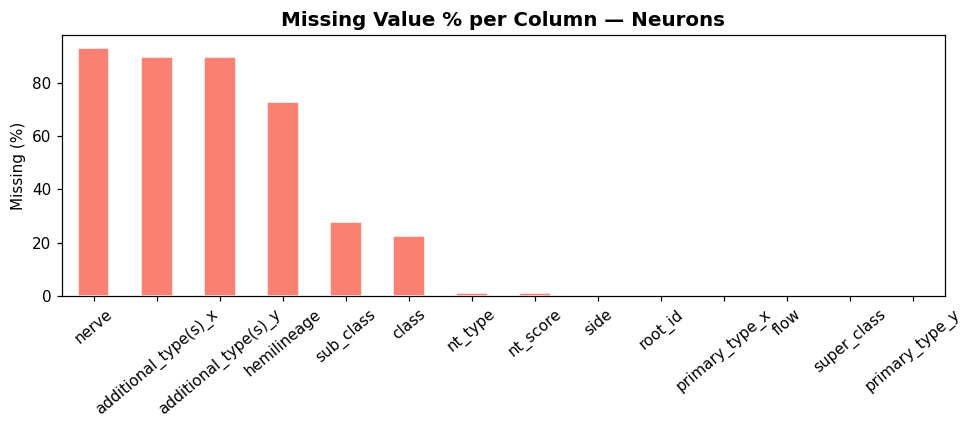

In [2]:
print('Shape:', neurons_df.shape)
print('\nDtypes:')
print(neurons_df.dtypes)
print('\nBasic stats:')
display(neurons_df.describe(include='all'))

miss = missing_data_summary(neurons_df)
print('\nMissing value summary:')
display(miss)

fig, ax = plt.subplots(figsize=(9, 4))
miss['missing_pct'].plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
ax.set_title('Missing Value % per Column — Neurons', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()

## 2. Top In/Out Region Distribution (Top 30)

Total unique regions: 10
super_class
optic                 77560
central               32235
sensory               16918
visual_projection      7667
ascending              1609
descending             1305
visual_centrifugal      516
sensory_ascending       327
motor                   110
endocrine                80
Name: count, dtype: int64


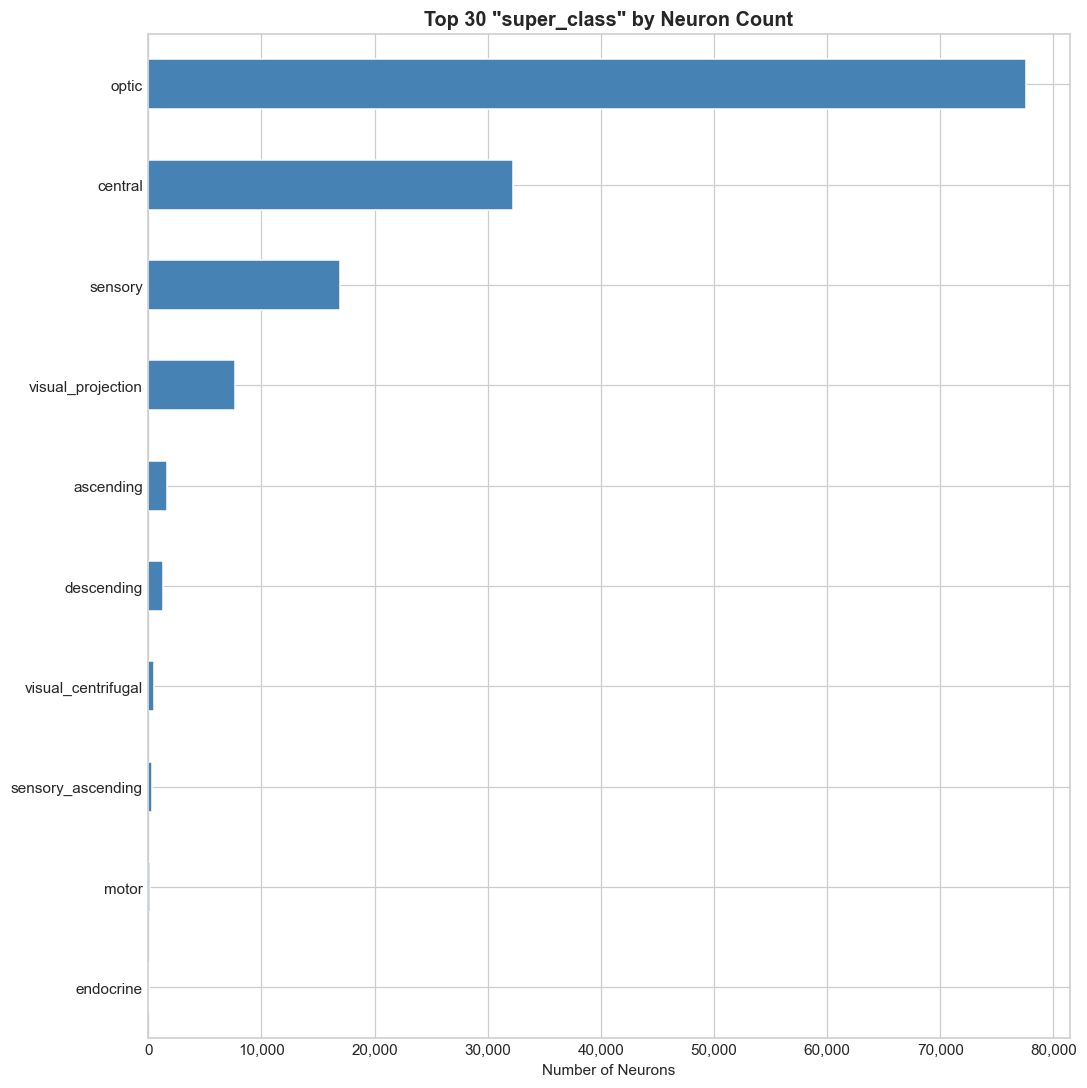

In [3]:
region_counts = neuron_region_counts(neurons_df, top_n=30)
print(f'Total unique regions: {neurons_df["super_class"].nunique()}')
print(region_counts)

plot_barh(
    region_counts,
    title='Top 30 "super_class" by Neuron Count',
    xlabel='Number of Neurons',
    figsize=(10, 10),
    color='steelblue',
)
plt.show()

## 3. Predicted NT Type Distribution

nt_type counts:
nt_type
ACH     93624
GLUT    22550
GABA    18299
SER      1418
DA        782
OCT       105
Name: count, dtype: int64


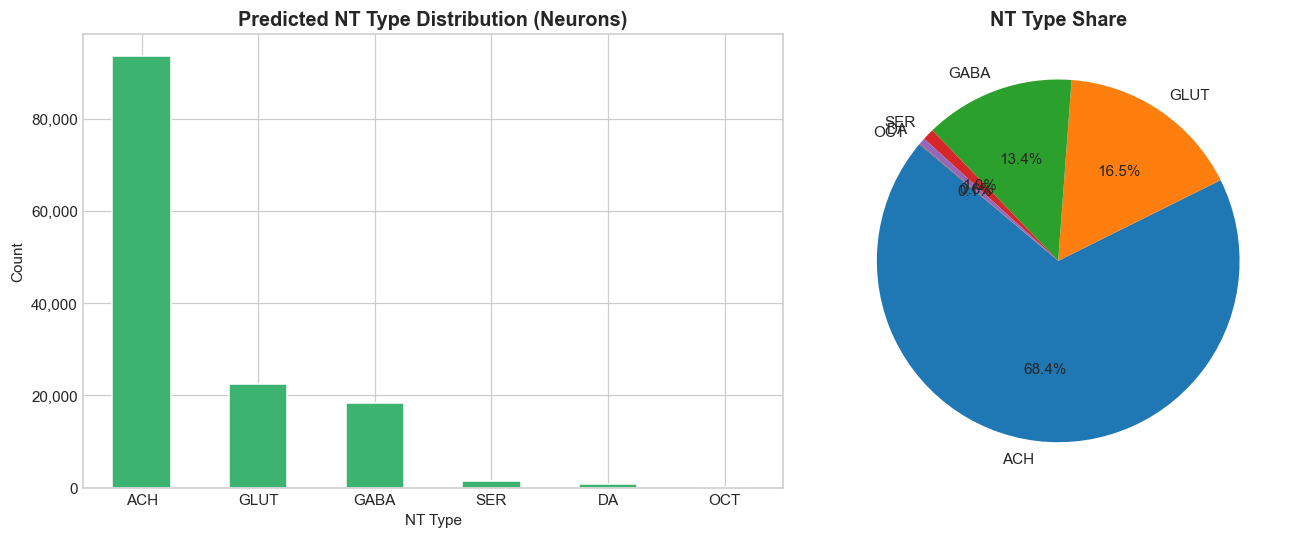

In [4]:
nt_counts = neuron_nt_type_counts(neurons_df)
print('nt_type counts:')
print(nt_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_bar(
    nt_counts,
    title='Predicted NT Type Distribution (Neurons)',
    xlabel='NT Type',
    color='mediumseagreen',
    rotate_xticks=0,
    ax=axes[0],
)

axes[1].pie(nt_counts.values, labels=nt_counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title('NT Type Share', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Predicted NT Confidence Distribution

NT Confidence stats:
count    136778.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: nt_score, dtype: float64


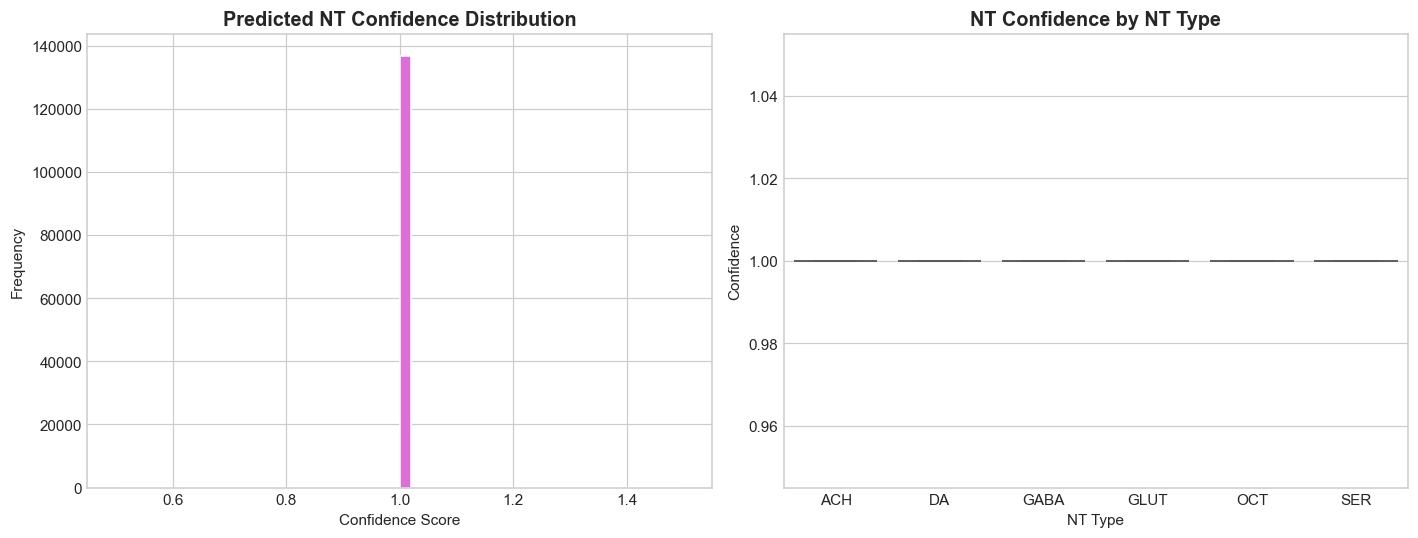

In [5]:
print('NT Confidence stats:')
print(neuron_nt_confidence_stats(neurons_df))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of confidence scores
plot_histogram(
    neurons_df['nt_score'],
    title='Predicted NT Confidence Distribution',
    xlabel='Confidence Score',
    bins=50,
    color='orchid',
    ax=axes[0],
)

# Confidence by NT type — box plot
nt_conf = neurons_df.dropna(subset=['nt_type', 'nt_score'])
order = nt_conf.groupby('nt_type')['nt_score'].median().sort_values(ascending=False).index
sns.boxplot(
    data=nt_conf,
    x='nt_type',
    y='nt_score',
    order=order,
    palette='Set2',
    ax=axes[1],
)
axes[1].set_title('NT Confidence by NT Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('NT Type')
axes[1].set_ylabel('Confidence')
plt.tight_layout()
plt.show()

## 5. side Distribution

side counts:
side
left      69431
right     68701
center      165
Name: count, dtype: int64


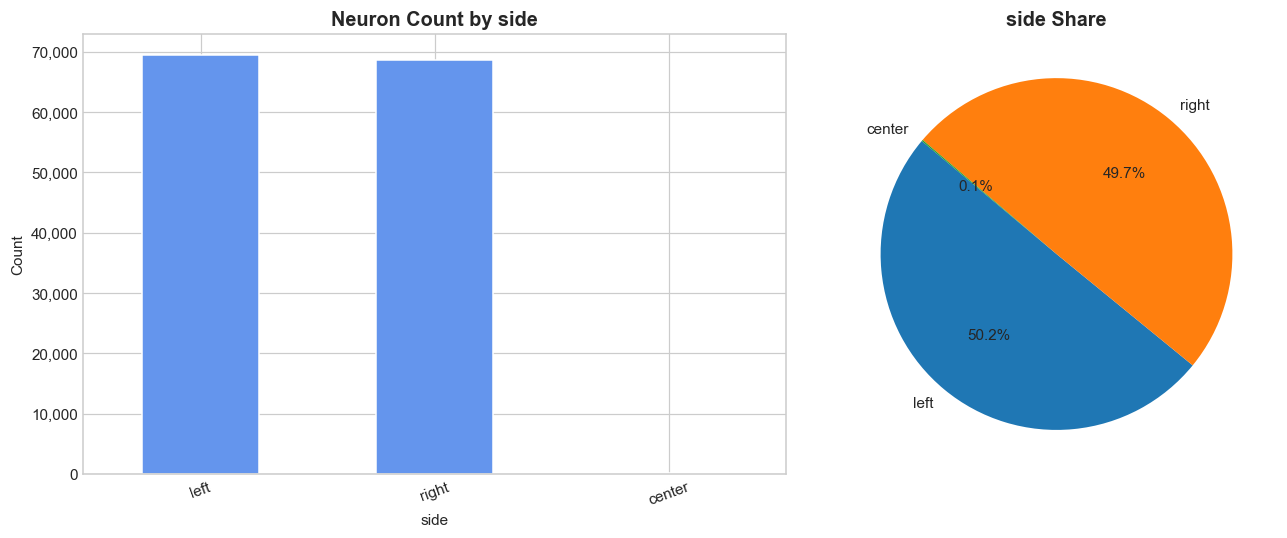

In [6]:
bp_counts = neuron_body_part_counts(neurons_df)
print('side counts:')
print(bp_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_bar(
    bp_counts,
    title='Neuron Count by side',
    xlabel='side',
    color='cornflowerblue',
    rotate_xticks=20,
    ax=axes[0],
)

axes[1].pie(bp_counts.values, labels=bp_counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title('side Share', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Community Labels (Top 20)

Total unique community labels: 117
sub_class
transmedullary            17996
photo_receptor            11151
lamina_monopolar           7952
medulla_intrinsic          7860
distal_medulla             6561
t4_neuron                  6243
t5_neuron                  6002
transmedullary_y           5285
t2_neuron                  3240
serpentine_medulla         2977
centrifugal                2968
KCg                        2490
t3_neuron                  1676
lobula_intrinsic           1518
t1_neuron                  1400
y_neuron                   1269
columnar                   1241
proximal_medulla           1214
eye_bristle                1113
lobula_plate_intrinsic      699
Name: count, dtype: int64


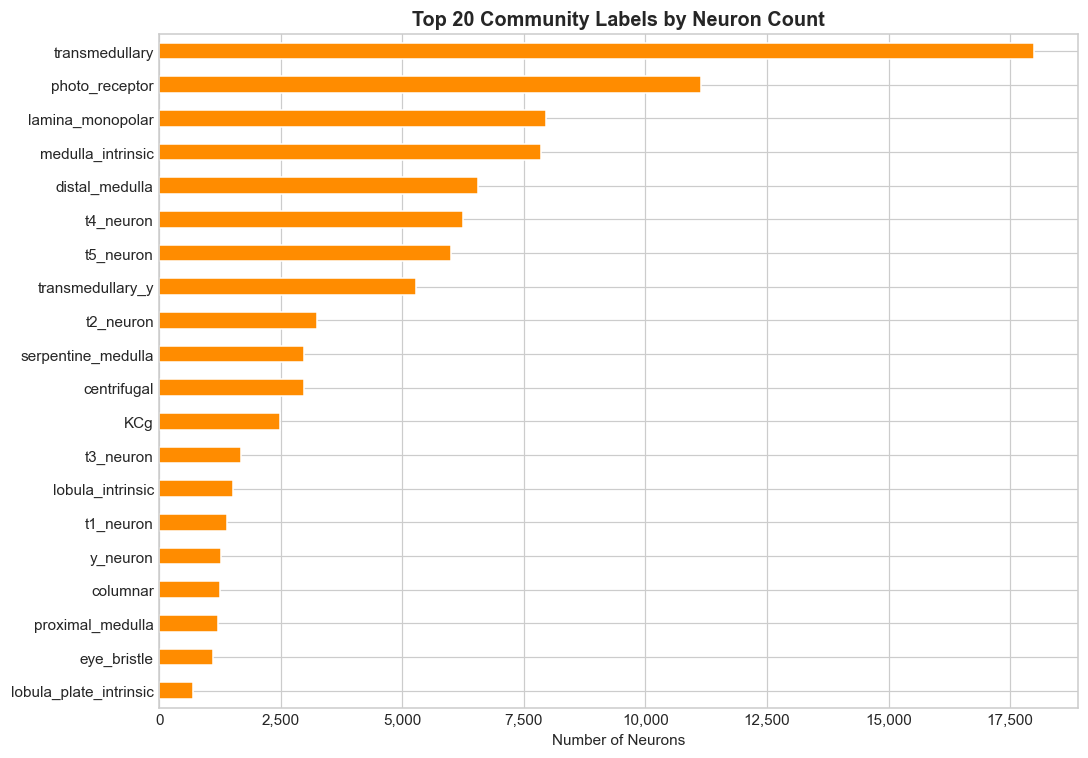

In [7]:
comm_counts = neuron_community_label_counts(neurons_df, top_n=20)
print(f'Total unique community labels: {neurons_df["sub_class"].nunique()}')
print(comm_counts)

plot_barh(
    comm_counts,
    title='Top 20 Community Labels by Neuron Count',
    xlabel='Number of Neurons',
    color='darkorange',
    figsize=(10, 7),
)
plt.show()

## 7. NT Type × side Heatmap

In [ ]:
# Cross-tabulation: NT type vs side
cross = (
    neurons_df
    .dropna(subset=['nt_type', 'side'])
    .groupby(['side', 'nt_type'])
    .size()
    .unstack(fill_value=0)
)
print('NT type x side counts:')
display(cross)

plot_heatmap(
    cross,
    title='Neuron Count: side × Predicted NT Type',
    figsize=(11, 5),
    fmt='d',
)
plt.show()

## 8. Top Region × NT Type Heatmap (Top 15 Regions)

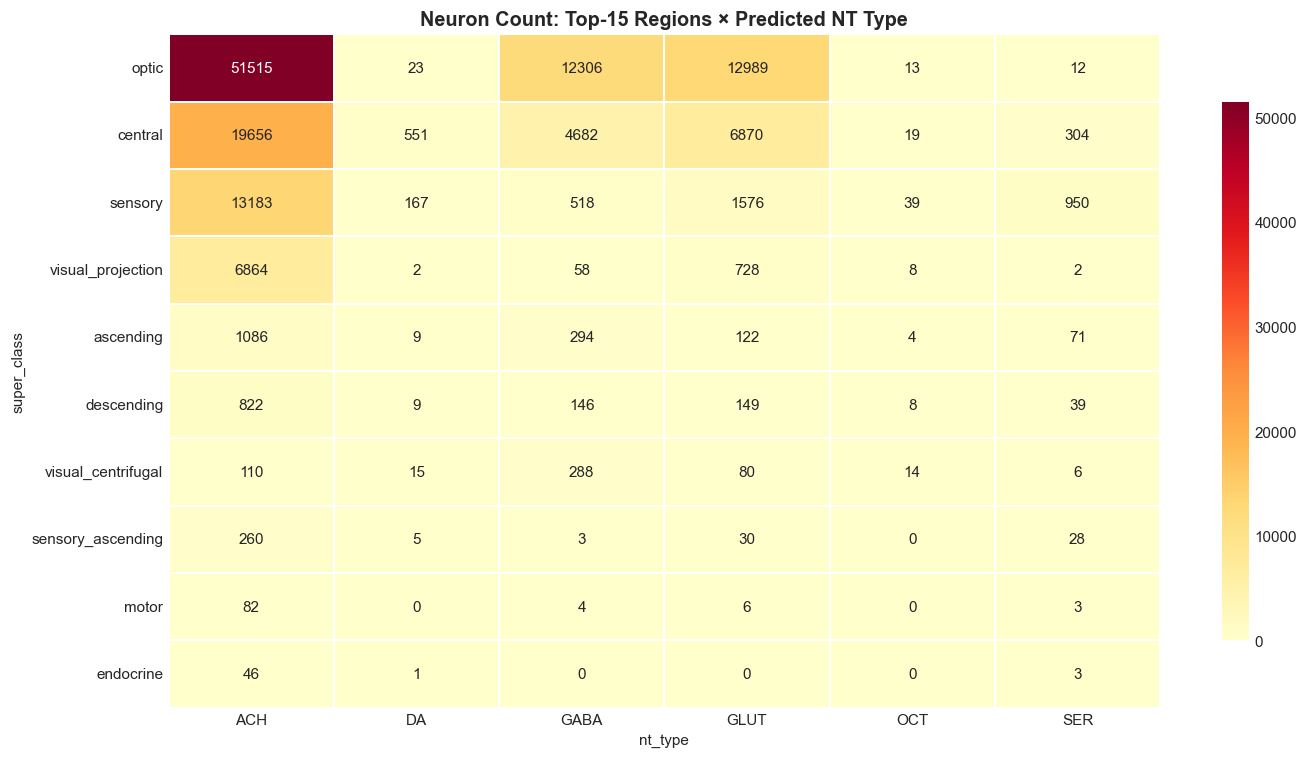

In [8]:
# Cross-tab: super_class vs nt_type
region_nt = (
    neurons_df
    .dropna(subset=['nt_type'])
    .groupby(['super_class', 'nt_type'])
    .size()
    .unstack(fill_value=0)
)
# Keep top 15 regions by total neuron count
top15_regions = region_nt.sum(axis=1).nlargest(15).index
region_nt_top = region_nt.loc[top15_regions]

plot_heatmap(
    region_nt_top,
    title='Neuron Count: Top-15 Regions × Predicted NT Type',
    figsize=(13, 7),
    fmt='d',
)
plt.show()

## 9. Verified vs Predicted NT Type Comparison

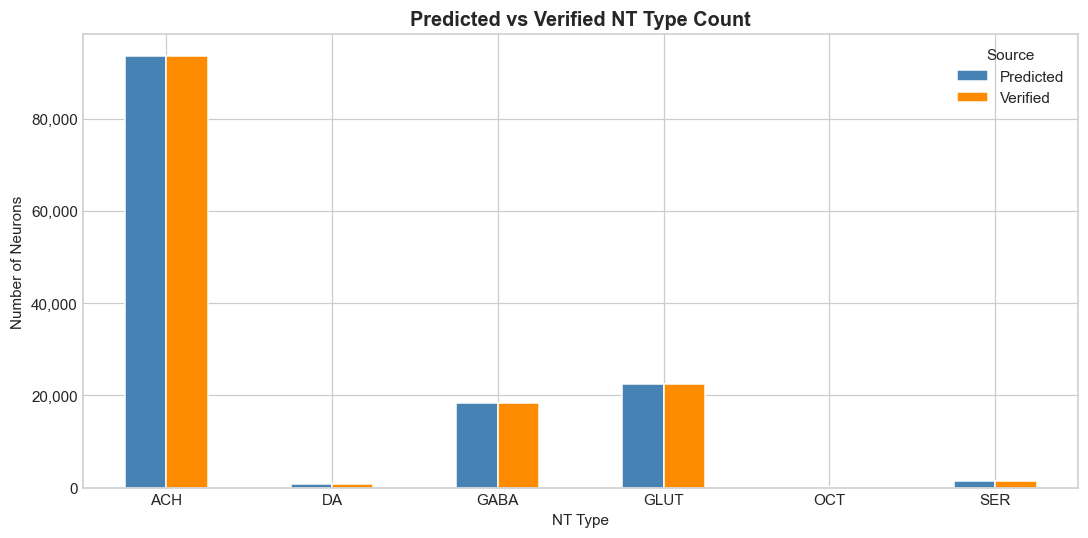

Neurons with verified NT type : 136,778
Neurons with predicted NT type: 136,778


In [9]:
verified = neurons_df['nt_type'].value_counts(dropna=True)
predicted = neurons_df['nt_type'].value_counts(dropna=True)

# Align on same index
all_types = sorted(set(verified.index) | set(predicted.index))
comp_df = pd.DataFrame({
    'Predicted': predicted.reindex(all_types, fill_value=0),
    'Verified':  verified.reindex(all_types, fill_value=0),
})

fig, ax = plt.subplots(figsize=(10, 5))
comp_df.plot(kind='bar', ax=ax, edgecolor='white', color=['steelblue', 'darkorange'])
ax.set_title('Predicted vs Verified NT Type Count', fontsize=13, fontweight='bold')
ax.set_xlabel('NT Type')
ax.set_ylabel('Number of Neurons')
ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Source')
plt.tight_layout()
plt.show()

print(f'Neurons with verified NT type : {verified.sum():,}')
print(f'Neurons with predicted NT type: {predicted.sum():,}')

## 10. Summary Statistics Table

In [ ]:
summary = {
    'Total neurons': len(neurons_df),
    'Unique regions (Top in/out)': neurons_df['super_class'].nunique(),
    'Unique community labels': neurons_df['sub_class'].nunique(),
    'Unique predicted NT types': neurons_df['nt_type'].nunique(),
    'Unique verified NT types': neurons_df['nt_type'].nunique(),
    'Neurons w/ predicted NT': neurons_df['nt_type'].notna().sum(),
    'Neurons w/ verified NT': neurons_df['nt_type'].notna().sum(),
    'Neurons w/ body part label': neurons_df['side'].notna().sum(),
    'Mean NT confidence': round(neurons_df['nt_score'].mean(), 3),
    'Median NT confidence': round(neurons_df['nt_score'].median(), 3),
}

for k, v in summary.items():
    if isinstance(v, int):
        print(f'{k:<40} {v:>12,}')
    else:
        print(f'{k:<40} {v:>12}')

# FAFB Dataset — Neuron Visualization

Exploratory visualization of `neurons.csv.gz` (115,151 neurons).

**Columns:** `root_id`, `super_class`, `sub_class`, `nt_type`, `nt_score`, `nt_type`, `nt_type`, `side`

In [10]:
import sys, os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from fafb_utils import (
    load_neurons,
    missing_data_summary,
    neuron_region_counts,
    neuron_nt_type_counts,
    neuron_body_part_counts,
    neuron_community_label_counts,
    neuron_nt_confidence_stats,
    plot_bar, plot_barh, plot_pie, plot_histogram,
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Imports OK')

Imports OK


## 1. Load Data

In [11]:
neurons_df = load_neurons()
print(f'Shape: {neurons_df.shape}')
print(f'Columns: {list(neurons_df.columns)}')
neurons_df.head()

Shape: (138327, 14)
Columns: ['root_id', 'primary_type_x', 'additional_type(s)_x', 'flow', 'super_class', 'class', 'sub_class', 'hemilineage', 'side', 'nerve', 'nt_type', 'nt_score', 'primary_type_y', 'additional_type(s)_y']


,root_id,primary_type_x,additional_type(s)_x,flow,super_class,class,sub_class,hemilineage,side,nerve,nt_type,nt_score,primary_type_y,additional_type(s)_y
0,720575940599457990,T4b,NaN,intrinsic,optic,optic_lobe_intrinsic,t4_neuron,NaN,right,NaN,ACH,1.0,T4b,NaN
1,720575940599763910,T5b,NaN,intrinsic,optic,optic_lobe_intrinsic,t5_neuron,NaN,right,NaN,ACH,1.0,T5b,NaN
2,720575940600623020,Dm3q,NaN,intrinsic,optic,optic_lobe_intrinsic,distal_medulla,NaN,right,NaN,GLUT,1.0,Dm3q,NaN
3,720575940602564320,KCg-m,NaN,intrinsic,central,Kenyon_Cell,KCg,MBp4,right,NaN,ACH,1.0,KCg-m,NaN
4,720575940602720940,JO-CA,NaN,afferent,sensory,mechanosensory,wind_gravity,NaN,left,AN,ACH,1.0,JO-CA,NaN


## 2. Missing Data Overview

In [ ]:
miss = missing_data_summary(neurons_df)
print(miss)

fig, ax = plt.subplots(figsize=(9, 4))
miss['missing_pct'].plot(kind='barh', ax=ax, color='salmon', edgecolor='white')
ax.set_title('Missing Data % per Column', fontsize=13, fontweight='bold')
ax.set_xlabel('Missing (%)')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Top In/Out Region Distribution

In [ ]:
region_counts = neuron_region_counts(neurons_df, top_n=25)
print(f"Total unique regions: {neurons_df['super_class'].nunique()}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_barh(region_counts, title='Top 25 Neuropil Regions (Neuron Count)',
          xlabel='Number of Neurons', color='steelblue', ax=axes[0])
plot_pie(region_counts, title='Region Distribution (Top 10)', max_slices=10, ax=axes[1])
plt.tight_layout()
plt.show()

## 4. side Distribution

In [ ]:
body_counts = neuron_body_part_counts(neurons_df)
print('side value counts:')
print(body_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_bar(body_counts, title='Neurons by side', xlabel='side',
         ylabel='Number of Neurons', color='mediumseagreen', ax=axes[0])
plot_pie(body_counts, title='side Proportion', max_slices=8, ax=axes[1])
plt.tight_layout()
plt.show()

## 5. Predicted Neurotransmitter (NT) Type

In [ ]:
nt_counts = neuron_nt_type_counts(neurons_df)
coverage = neurons_df['nt_type'].notna().mean() * 100
print(f'Prediction coverage: {coverage:.1f}% of neurons')
print(nt_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_bar(nt_counts, title='Predicted NT Type Distribution',
         xlabel='NT Type', ylabel='Number of Neurons',
         color='mediumpurple', ax=axes[0])
plot_pie(nt_counts, title='NT Type Proportion', max_slices=10, ax=axes[1])
plt.tight_layout()
plt.show()

## 6. NT Prediction Confidence

In [ ]:
print('Confidence statistics:')
print(neuron_nt_confidence_stats(neurons_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_histogram(neurons_df['nt_score'],
               title='NT Confidence Distribution',
               xlabel='Confidence Score', bins=40,
               color='darkorange', ax=axes[0])

sub = neurons_df.dropna(subset=['nt_type', 'nt_score'])
sub.boxplot(column='nt_score', by='nt_type',
            ax=axes[1], grid=True)
axes[1].set_title('Confidence by NT Type')
axes[1].set_xlabel('NT Type')
axes[1].set_ylabel('Confidence')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 7. Community Labels

In [ ]:
community_counts = neuron_community_label_counts(neurons_df, top_n=25)
coverage_c = neurons_df['sub_class'].notna().mean() * 100
print(f'Community label coverage: {coverage_c:.1f}%')
print(f"Total unique labels: {neurons_df['sub_class'].nunique()}")

plot_barh(community_counts,
          title='Top 25 Community Labels',
          xlabel='Number of Neurons',
          color='teal', figsize=(10, 7))
plt.show()

## 8. Verified vs Predicted NT Type

In [ ]:
both = neurons_df.dropna(subset=['nt_type', 'nt_type']).copy()
print(f'Neurons with both predicted and verified NT: {len(both)}')

if len(both) > 0:
    both['match'] = both['nt_type'] == both['nt_type']
    agreement = both['match'].mean() * 100
    print(f'Agreement rate: {agreement:.1f}%')
    confusion = pd.crosstab(both['nt_type'], both['nt_type'])
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', ax=ax,
                linewidths=0.5, cbar_kws={'shrink': 0.7})
    ax.set_title(f'Predicted vs Verified NT Type (agreement: {agreement:.1f}%)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Verified NT Type')
    ax.set_ylabel('Predicted NT Type')
    plt.tight_layout()
    plt.show()
else:
    verified = neurons_df['nt_type'].value_counts(dropna=True)
    if len(verified) > 0:
        plot_bar(verified, title='Verified NT Type Distribution', xlabel='NT Type', color='teal')
        plt.show()
    else:
        print('No verified NT type data available.')

## 9. NT Type Distribution per side (Stacked Bar)

In [ ]:
sub = neurons_df.dropna(subset=['nt_type', 'side'])
pivot = pd.crosstab(sub['side'], sub['nt_type'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10', edgecolor='none')
axes[0].set_title('NT Type Count by side', fontsize=12, fontweight='bold')
axes[0].set_xlabel('side')
axes[0].set_ylabel('Neuron Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='NT Type', bbox_to_anchor=(1.0, 1.0))

pivot_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10', edgecolor='none')
axes[1].set_title('NT Type % by side', fontsize=12, fontweight='bold')
axes[1].set_xlabel('side')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='NT Type', bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.show()

## 10. Summary Statistics

In [ ]:
summary = pd.DataFrame({
    'Total neurons': [len(neurons_df)],
    'Unique regions': [neurons_df['super_class'].nunique()],
    'Unique body parts': [neurons_df['side'].nunique()],
    'NT type coverage (%)': [round(neurons_df['nt_type'].notna().mean()*100, 1)],
    'Verified NT coverage (%)': [round(neurons_df['nt_type'].notna().mean()*100, 1)],
    'Community label coverage (%)': [round(neurons_df['sub_class'].notna().mean()*100, 1)],
    'Mean NT confidence': [round(neurons_df['nt_score'].mean(), 3)],
}).T
summary.columns = ['Value']
summary